In [234]:
import torch.nn as nn
from typing import Any
from torch import Tensor
import torch

In [235]:
from blocks.ddpm_blocks import UpBlockUnet, MidBlock, DownBlock

In [236]:
import numpy as np
from tqdm import tqdm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

########################
# Replace config dicts with variables
num_timesteps = 100
beta_start = 0.0001
beta_end = 0.02

dataset_name = "mnist"
im_path = "mnist/"
im_size = 32
im_channels = 1

# Must match VQVAE.z_channels (the VAE encodes to a 3-channel latent)
z_channels = 3

EPOCHS = 10
IMAGE_CHANNELS = 1

task_name = "vqvae_train"
vqvae_latent_dir_name = 0
ldm_batch_size = 0
vqvae_autoencoder_ckpt_name = "vqvae"
ldm_epochs = 10
ldm_lr = 2e-4
ldm_ckpt_name = "ddpm_class_cond"

# Condition config variables
condition_types = ["image"]
image_condition_config = {
    "image_condition_input_channels": 18,
    "image_condition_output_channels": 3, 
    "image_condition_h": 512, 
    "image_condition_w": 512, 
    "cond_drop_prob": 0.1 
}
text_embed_dim = 256
class_cond_drop_prob = 0.0
use_latents = True


# Instantiate Condition related components
text_tokenizer = None
text_model = None
empty_text_embed = None

# Support for easily checking if we should use condition
use_condition = condition_types is not None and len(condition_types) > 0


In [237]:
import glob
import os
import random
import torch
import torchvision
from PIL import Image
from torch.utils.data.dataset import Dataset
import json
import pickle


def load_latents(latent_path):
    r"""
    Simple utility to save latents to speed up ldm training
    :param latent_path:
    :return:
    """
    latent_maps = {}
    for fname in glob.glob(os.path.join(latent_path, "*.pkl")):
        s = pickle.load(open(fname, "rb"))
        for k, v in s.items():
            latent_maps[k] = v[0]
    return latent_maps

class CelebDataset(Dataset):
    r"""
    Celeb dataset will by default centre crop and resize the images.
    This can be replaced by any other dataset. As long as all the images
    are under one directory.
    """
    
    def __init__(self, split, im_path, im_size=256, im_channels=3, im_ext='jpg',
                 use_latents=False, latent_path=None, condition_config=None):
        self.split = split
        self.im_size = im_size
        self.im_channels = im_channels
        self.im_ext = im_ext
        self.im_path = im_path
        self.latent_maps = None
        self.use_latents = False
        
        self.condition_types = [] if condition_config is None else condition_config['condition_types']
        
        self.idx_to_cls_map = {}
        self.cls_to_idx_map ={}
        
        if 'image' in self.condition_types:
            self.mask_channels = condition_config['image_condition_config']['image_condition_input_channels']
            self.mask_h = condition_config['image_condition_config']['image_condition_h']
            self.mask_w = condition_config['image_condition_config']['image_condition_w']
            
        self.images, self.texts, self.masks = self.load_images(im_path)
        
        # Whether to load images or to load latents
        if use_latents and latent_path is not None:
            latent_maps = load_latents(latent_path)
            if len(latent_maps) == len(self.images):
                self.use_latents = True
                self.latent_maps = latent_maps
                print('Found {} latents'.format(len(self.latent_maps)))
            else:
                print('Latents not found')
    
    def load_images(self, im_path):
        r"""
        Gets all images from the path specified
        and stacks them all up
        """
        assert os.path.exists(im_path), "images path {} does not exist".format(im_path)
        ims = []
        fnames = glob.glob(os.path.join(im_path, 'CelebA-HQ-img/*.{}'.format('png')))
        fnames += glob.glob(os.path.join(im_path, 'CelebA-HQ-img/*.{}'.format('jpg')))
        fnames += glob.glob(os.path.join(im_path, 'CelebA-HQ-img/*.{}'.format('jpeg')))
        texts = []
        masks = []
        
        if 'image' in self.condition_types:
            label_list = ['skin', 'nose', 'eye_g', 'l_eye', 'r_eye', 'l_brow', 'r_brow', 'l_ear', 'r_ear', 'mouth',
                          'u_lip', 'l_lip', 'hair', 'hat', 'ear_r', 'neck_l', 'neck', 'cloth']
            self.idx_to_cls_map = {idx: label_list[idx] for idx in range(len(label_list))}
            self.cls_to_idx_map = {label_list[idx]: idx for idx in range(len(label_list))}
            
            
        captions = json.load(open( os.path.join( im_path,"celeba-caption", "captions_hq.json")))
        
        for fname in tqdm(fnames):
            ims.append(fname)
            
            if 'text' in self.condition_types:
                im_name = os.path.split(fname)[1].split('.')[0]
                captions_im = [captions[str(int(fname.split(".")[0])) + "." + fname.split(".")[1]]["overall_caption"]]
                texts.append(captions_im)
                
            if 'image' in self.condition_types:
                im_name = int(os.path.split(fname)[1].split('.')[0])
                masks.append(os.path.join(im_path, 'CelebAMask-HQ-mask/unified/', '{}.png'.format(im_name)))
        if 'text' in self.condition_types:
            assert len(texts) == len(ims), "Condition Type Text but could not find captions for all images"
        if 'image' in self.condition_types:
            assert len(masks) == len(ims), "Condition Type Image but could not find masks for all images"
        print('Found {} images'.format(len(ims)))
        print('Found {} masks'.format(len(masks)))
        print('Found {} captions'.format(len(texts)))
        return ims, texts, masks
    
    def get_mask(self, index):
        mask_im = Image.open(self.masks[index]).convert("L")     # 1-channel, H×W
        mask_im = np.array(mask_im)
        assert mask_im.ndim == 2, f"expected 2D index mask, got {mask_im.shape}"

        im_base = np.zeros((self.mask_h, self.mask_w, self.mask_channels), dtype=np.float32)
        for orig_idx in range(len(self.idx_to_cls_map)):
            im_base[mask_im == (orig_idx + 1), orig_idx] = 1.0

        return torch.from_numpy(im_base).permute(2, 0, 1).float()
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, index):
        ######## Set Conditioning Info ########
        cond_inputs = {}
        if 'text' in self.condition_types:
            cond_inputs['text'] = random.sample(self.texts[index], k=1)[0]
        if 'image' in self.condition_types:
            mask = self.get_mask(index)
            cond_inputs['image'] = mask
        #######################################
        
        if self.use_latents:
            latent = self.latent_maps[self.images[index]]
            if len(self.condition_types) == 0:
                return latent
            else:
                return latent, cond_inputs
        else:
            im = Image.open(self.images[index])
            im_tensor = torchvision.transforms.Compose([
                torchvision.transforms.Resize(self.im_size),
                torchvision.transforms.CenterCrop(self.im_size),
                torchvision.transforms.ToTensor(),
            ])(im)
            im.close()
        
            # Convert input to -1 to 1 range.
            im_tensor = (2 * im_tensor) - 1
            if len(self.condition_types) == 0:
                return im_tensor
            else:
                return im_tensor, cond_inputs
   

In [238]:
dataset = CelebDataset(
    split='train', 
    im_path = "celeba", 
    im_size = 512, 
    condition_config  = { "condition_types": ["image"],  "image_condition_config" : {
        
    "image_condition_input_channels": 18,
    "image_condition_output_channels": 3, 
    "image_condition_h": 512, 
    "image_condition_w": 512, 
    "cond_drop_prob": 0.1 
}}
)
dataset.images = [ x for x in dataset.images if  int(x.split("/")[-1].split(".")[0])  < 100]
dataset.masks = [ x for x in dataset.masks if  int(x.split("/")[-1].split(".")[0])  < 100]

100%|██████████| 30000/30000 [00:00<00:00, 1262621.99it/s]

Found 30000 images
Found 30000 masks
Found 0 captions


In [239]:
from torch.utils.data import DataLoader
loader = DataLoader(
    dataset, batch_size = 8, 
    shuffle= False
)

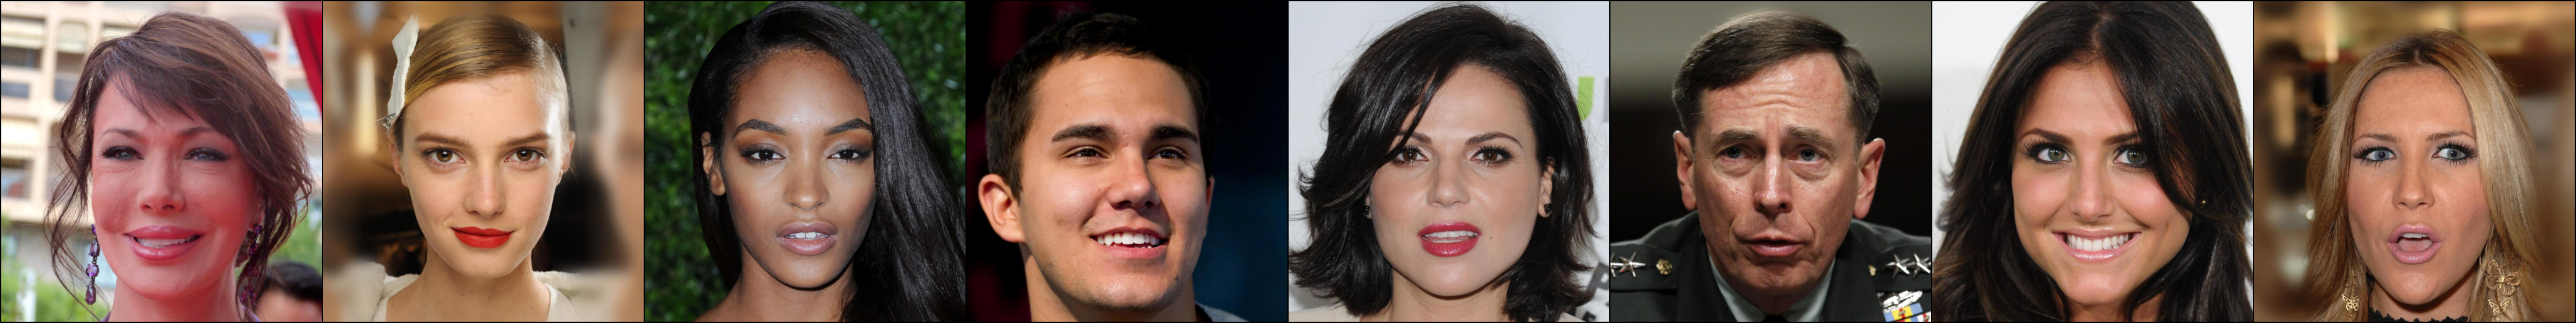

In [240]:
batch = next(iter(loader))[0]
batch = (batch + 1) / 2                       # [-1, 1] → [0, 1]
batch = batch.clamp(0, 1)                     # belt and suspenders
torchvision.transforms.ToPILImage()(torchvision.utils.make_grid(batch))

In [232]:
import os, glob
import numpy as np
from PIL import Image
from tqdm import tqdm

LABELS = ['skin','nose','eye_g','l_eye','r_eye','l_brow','r_brow',
          'l_ear','r_ear','mouth','u_lip','l_lip','hair','hat',
          'ear_r','neck_l','neck','cloth']

SRC = "celeba/CelebAMask-HQ-mask"           # has subfolders 0..14 with per-part PNGs
DST = "celeba/CelebAMask-HQ-mask/unified"
os.makedirs(DST, exist_ok=True)

# CelebAMask-HQ filenames are zero-padded to 5 digits: 00000_skin.png ... 29999_cloth.png
all_files = glob.glob(os.path.join(SRC, "[0-9]*", "*_*.png"))
ids = sorted({int(os.path.basename(p).split("_")[0]) for p in all_files})

for img_id in tqdm(ids):
    unified = None
    for cls_idx, label in enumerate(LABELS, start=1):    # 1..18
        # the per-part file lives in one of the subfolders 0..14
        matches = glob.glob(os.path.join(SRC, "*", f"{img_id:05d}_{label}.png"))
        if not matches:
            continue
        binary = np.array(Image.open(matches[0]).convert("L")) > 0
        if unified is None:
            unified = np.zeros(binary.shape, dtype=np.uint8)
        unified[binary] = cls_idx                         # overwrite — order matters

    if unified is None:
        continue
    # save WITHOUT a palette so .convert("L") in get_mask reads raw indices
    Image.fromarray(unified, mode="L").save(os.path.join(DST, f"{img_id}.png"))

100%|██████████| 30000/30000 [04:58<00:00, 100.45it/s]


In [ ]:
m = np.array(Image.open("celeba/CelebAMask-HQ-mask/unified/0.png").convert("L"))
print("unique values:", sorted(np.unique(m).tolist()))

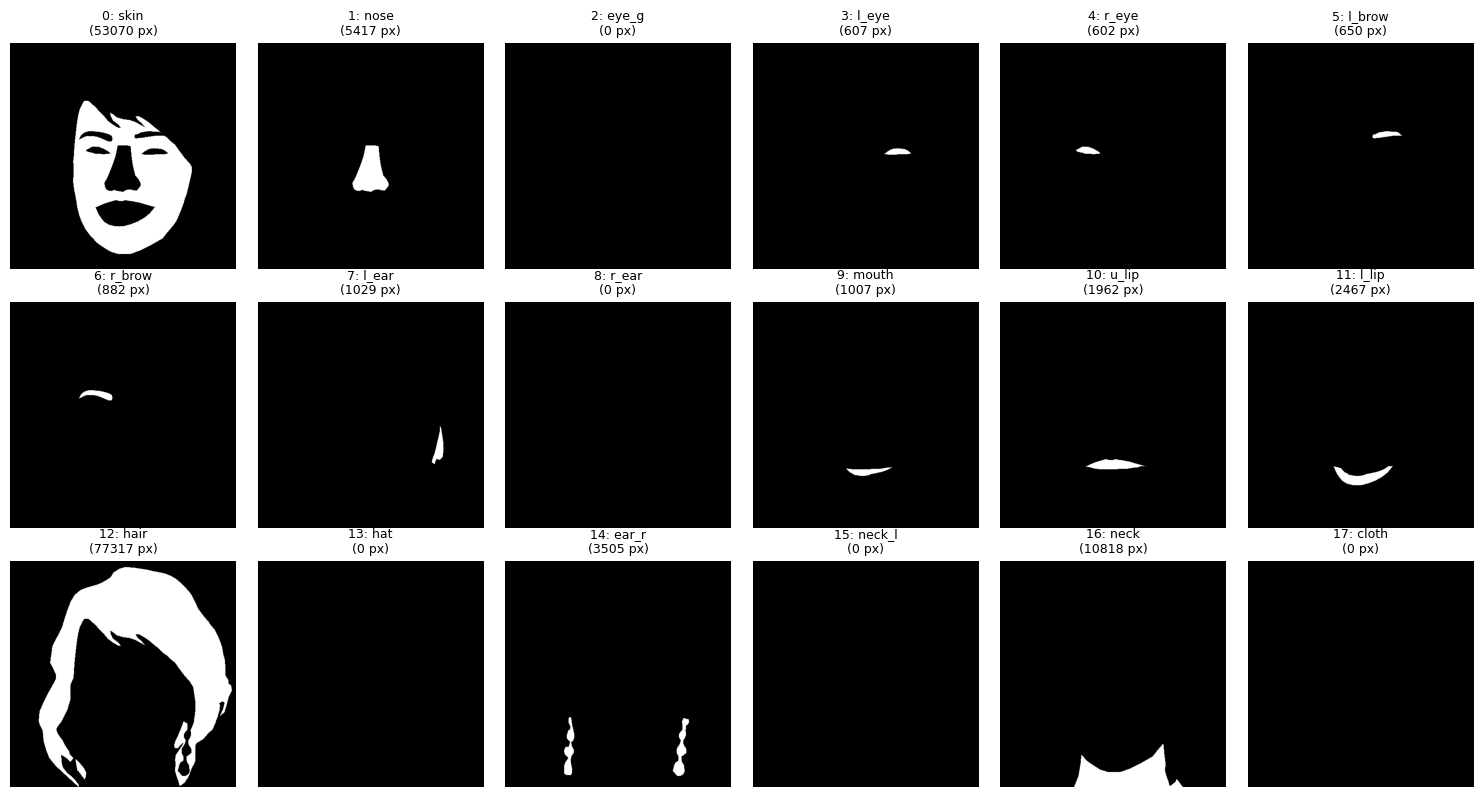

In [243]:
import matplotlib.pyplot as plt

LABELS = ['skin', 'nose', 'eye_g', 'l_eye', 'r_eye', 'l_brow', 'r_brow',
          'l_ear', 'r_ear', 'mouth', 'u_lip', 'l_lip', 'hair', 'hat',
          'ear_r', 'neck_l', 'neck', 'cloth']

batch = next(iter(loader))
mask = batch[1]['image'][0]   # [18, H, W] — first sample of the batch

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(mask[i].numpy(), cmap='gray', vmin=0, vmax=1)
    on = int(mask[i].sum().item())
    ax.set_title(f"{i}: {LABELS[i]}\n({on} px)", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [1]:
import os

# Step 1: Create the required folder structure for CelebA dataset.
celeba_root = "celeba"
img_dir = os.path.join(celeba_root, "CelebA-HQ-img")
mask_dir = os.path.join(celeba_root, "CelebAMask-HQ-mask")
caption_dir = os.path.join(celeba_root, "celeba-caption")

os.makedirs(img_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)
os.makedirs(caption_dir, exist_ok=True)

# Step 2: Download and save CelebA images to the image directory (if needed)
from torchvision.transforms import ToTensor
import torchvision

# Download CelebA dataset using torchvision (original images, not HQ)
# If you have HQ versions, move them to img_dir manually
dataset = torchvision.datasets.CelebA(root=celeba_root, download=True, split="all", transform=ToTensor())

# Step 3: Save each CelebA image in the correct directory as PNG
for idx in range(len(dataset)):
    img, target = dataset[idx]
    fpath = os.path.join(img_dir, f"{idx+1}.png")
    if not os.path.exists(fpath):
        torchvision.utils.save_image(img, fpath)

print(f"Saved {len(dataset)} images to {img_dir}.")

# Step 4: Place mask and caption files in their folders (if available).
# Note: Actual mask and caption file creation should be handled outside this code,
#       or you should provide those datasets if needed.

KeyboardInterrupt: 

In [ ]:
CelebDataset(
    split = 'train', 
    im_path = "celeba", 
    use_latents = False
)

In [ ]:


def get_time_embedding(t: Tensor, t_emb_dim):
    factor = 10000 ** (
        (
            torch.arange(
                start=0, end=t_emb_dim // 2, dtype=torch.float32, device=t.device
            )
        )
        / (t_emb_dim // 2)
    )

    t_emb = t[:, None].repeat(1, t_emb_dim // 2) / factor
    t_emb = torch.cat([torch.sin(t_emb), torch.cos(t_emb)], dim=1)

    return t_emb
class UnetCondImage(nn.Module):
    def __init__(self, im_channels: int = 3, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)

        self.down_channels = [64, 128, 256, 256]
        self.mid_channels = [256, 256]
        self.t_emb_dim = 256
        # No spatial down/up-sampling: the VAE latent is already tiny (4x4),
        # so further halving would collapse it to a zero-sized feature map.
        self.down_sample = [False, False, False]
        self.num_down_layers = 2
        self.num_mid_layers = 2
        self.num_up_layers = 2
        self.norm_channels = 32
        self.attns = [True, True, True]
        self.num_heads = 16
        # Predict noise in the latent space -> output channels must equal input (z) channels.
        self.conv_out_channels = im_channels

        ######## Class, Mask and Text Conditioning Config #####
        self.class_cond = False
        self.text_cond = False
        self.image_cond = False
        self.text_embed_dim = None
        self.condition_config = {
            "condition_types": ["class"],
            "class_condition_config": {
                "num_classes": 10,
            },
            "text_condition_config": {
                "text_embed_dim": 256,
            },
            "image_condition_config": {
                "image_condition_input_channels": 1,
                "image_condition_output_channels": 1,
            },
        }
        condition_types = self.condition_config["condition_types"]  # ["class", "text", "image"]
        if self.condition_config is not None:
            assert "condition_types" in self.condition_config, (
                "Condition Type not provided in model config"
            )
            if "class" in condition_types:
                # validate_class_config(self.condition_config)
                self.class_cond = True
                self.num_classes = self.condition_config["class_condition_config"][
                    "num_classes"
                ]
            if "text" in condition_types:
                self.text_cond = True
                self.text_embed_dim = self.condition_config["text_condition_config"][
                    "text_embed_dim"
                ]
            if "image" in condition_types:
                self.image_cond = True
                self.im_cond_input_ch = self.condition_config["image_condition_config"][
                    "image_condition_input_channels"
                ]
                self.im_cond_output_ch = self.condition_config[
                    "image_condition_config"
                ]["image_condition_output_channels"]
        if self.class_cond:
            # Rather than using a special null class we dont add the
            # class embedding information for unconditional generation
            self.class_emb = nn.Embedding(self.num_classes, self.t_emb_dim)

        if self.image_cond:
            # Map the mask image to a N channel image and
            # concat that with input across channel dimension
            self.cond_conv_in = nn.Conv2d(
                in_channels=self.im_cond_input_ch,
                out_channels=self.im_cond_output_ch,
                kernel_size=1,
                bias=False,
            )
            self.conv_in_concat = nn.Conv2d(
                im_channels + self.im_cond_output_ch,
                self.down_channels[0],
                kernel_size=3,
                padding=1,
            )
        else:
            self.conv_in = nn.Conv2d(
                im_channels, self.down_channels[0], kernel_size=3, padding=1
            )
        self.cond = self.text_cond or self.image_cond or self.class_cond
        ###################################

        self.t_proj = nn.Sequential(
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
            nn.SiLU(),
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
        )

        self.downs = nn.ModuleList()
        for i in range(len(self.down_channels) - 1):
            self.downs.append(
                DownBlock(
                    self.down_channels[i],
                    self.down_channels[i + 1],
                    self.t_emb_dim,
                    down_sample=self.down_sample[i],
                    num_heads=self.num_heads,
                    num_layers=self.num_down_layers,
                    attn=self.attns[i],
                    norm_channels=self.norm_channels,
                )
            )

        self.mids = nn.ModuleList()
        for i in range(len(self.mid_channels) - 1):
            self.mids.append(
                MidBlock(
                    self.mid_channels[i],
                    self.mid_channels[i + 1],
                    self.t_emb_dim,
                    num_heads=self.num_heads,
                    num_layers=self.num_down_layers,
                    norm_channels=self.norm_channels,
                )
            )

        self.ups = nn.ModuleList()
        for i in reversed(range(len(self.down_channels) - 1)):
            # print(
            #     "In Channels", self.down_channels[i] * 2
            # )
            # print("Out Channels", self.down_channels[i - 1] if i != 0 else self.down_channels[0])
            self.ups.append(
                UpBlockUnet(
                    self.down_channels[i] * 2,
                    self.down_channels[i - 1] if i != 0 else self.down_channels[0],
                    up_sample=self.down_sample[i],
                    t_emb_dim=self.t_emb_dim,
                    num_heads=self.num_heads,
                    num_layers=self.num_down_layers,
                    norm_channels=self.norm_channels,
                )
            )

        self.norm_out = nn.GroupNorm(
            self.norm_channels,
            self.down_channels[0],  # was self.conv_out_channels
        )
        self.conv_out = nn.Conv2d(
            self.down_channels[0],
            self.conv_out_channels,
            kernel_size=3,
            padding=1,
        )
        
        
    def forward(self, x, t, cond_input = None):
         # shapes assuiming dowblocks - [c1, c2, c3,c4 ...]
        # shapes midblocks - [c4, c4, c3]
        # up samples - [c3, c2, c1]
        #### conditioning part
        if self.image_cond:
            validate_image_conditional_input(cond_input, x)
            im_cond = cond_input["image"]
            im_cond = torch.nn.functional.interpolate(im_cond, size = x.shape[-2:])
            im_cond = self.cond_conv_in(im_cond)
            assert im_cond.shape[-2:] == x.shape[-2:]
            # B X (C + N) X H X W
            out = self.conv_in_concat(x)
            ###########
        else:
            # B X C X H X W
            out = self.conv_in(x)
        
        
        
        # B X C1 X H X W
        t_emb = get_time_embedding(torch.as_tensor(t).long(), self.t_emb_dim)
        t_emb = self.t_proj(t_emb)
    
        #### conditioning part

        down_outs = []
        for idx, down in enumerate(self.downs):
            down_outs.append(out)
            out = down(out, t_emb)

        for mid in self.mids:
            out = mid(out, t_emb)

        self.up_outs = []
        for idx, up in enumerate(self.ups):
            down_out = down_outs.pop()
            out = up(out, down_out, t_emb)

        out = self.norm_out(out)
        out = nn.SiLU()(out)
        out = self.conv_out(out)
        return out

In [ ]:
def drop_image_condition(image_condition, im, im_drop_prob):
    if im_drop_prob > 0:
        im_drop_mask = (
            torch.zeros((im.shape[0], 1, 1, 1), device=im.device).float().uniform_(0, 1)
            > im_drop_prob
        )
        return image_condition * im_drop_mask
    else:
        return image_condition


In [ ]:
import torch
import numpy as np


class LinearNoiseScheduler:
    r"""
    Class for the linear noise scheduler that is used in DDPM.
    """
    
    def __init__(self, num_timesteps, beta_start, beta_end):
        self.num_timesteps = num_timesteps
        self.beta_start = beta_start
        self.beta_end = beta_end
        # Mimicking how compvis repo creates schedule
        self.betas = (
                torch.linspace(beta_start ** 0.5, beta_end ** 0.5, num_timesteps) ** 2
        )
        self.alphas = 1. - self.betas
        self.alpha_cum_prod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_cum_prod = torch.sqrt(self.alpha_cum_prod)
        self.sqrt_one_minus_alpha_cum_prod = torch.sqrt(1 - self.alpha_cum_prod)
    
    def add_noise(self, original, noise, t):
        r"""
        Forward method for diffusion
        :param original: Image on which noise is to be applied
        :param noise: Random Noise Tensor (from normal dist)
        :param t: timestep of the forward process of shape -> (B,)
        :return:
        """
        original_shape = original.shape
        batch_size = original_shape[0]
        
        sqrt_alpha_cum_prod = self.sqrt_alpha_cum_prod.to(original.device)[t].reshape(batch_size)
        sqrt_one_minus_alpha_cum_prod = self.sqrt_one_minus_alpha_cum_prod.to(original.device)[t].reshape(batch_size)
        
        # Reshape till (B,) becomes (B,1,1,1) if image is (B,C,H,W)
        for _ in range(len(original_shape) - 1):
            sqrt_alpha_cum_prod = sqrt_alpha_cum_prod.unsqueeze(-1)
        for _ in range(len(original_shape) - 1):
            sqrt_one_minus_alpha_cum_prod = sqrt_one_minus_alpha_cum_prod.unsqueeze(-1)
        
        # Apply and Return Forward process equation
        return (sqrt_alpha_cum_prod.to(original.device) * original
                + sqrt_one_minus_alpha_cum_prod.to(original.device) * noise)
    
    def sample_prev_timestep(self, xt, noise_pred, t):
        r"""
            Use the noise prediction by model to get
            xt-1 using xt and the nosie predicted
        :param xt: current timestep sample
        :param noise_pred: model noise prediction
        :param t: current timestep we are at
        :return:
        """
        x0 = ((xt - (self.sqrt_one_minus_alpha_cum_prod.to(xt.device)[t] * noise_pred)) /
              torch.sqrt(self.alpha_cum_prod.to(xt.device)[t]))
        x0 = torch.clamp(x0, -1., 1.)
        
        mean = xt - ((self.betas.to(xt.device)[t]) * noise_pred) / (self.sqrt_one_minus_alpha_cum_prod.to(xt.device)[t])
        mean = mean / torch.sqrt(self.alphas.to(xt.device)[t])
        
        if t == 0:
            return mean, x0
        else:
            variance = (1 - self.alpha_cum_prod.to(xt.device)[t - 1]) / (1.0 - self.alpha_cum_prod.to(xt.device)[t])
            variance = variance * self.betas.to(xt.device)[t]
            sigma = variance ** 0.5
            z = torch.randn(xt.shape).to(xt.device)
            
            # OR
            # variance = self.betas[t]
            # sigma = variance ** 0.5
            # z = torch.randn(xt.shape).to(xt.device)
            return mean + sigma * z, x0
        
        
        
########## Create the noise scheduler #############
scheduler = LinearNoiseScheduler(
    num_timesteps=num_timesteps,
    beta_start=beta_start,
    beta_end=beta_end,
)
###############################################

In [ ]:

# Instantiate the unet model_cond
from torch.optim import Adam
from models.vqvae import VQVAE


model_cond = UnetCondImage(im_channels=z_channels).to(device)
model_cond.train()

vae = None
# Load VAE ONLY if latents are not to be saved or some are missing
print("Loading vqvae model_cond as latents not present")
vae = VQVAE(
    im_channels=im_channels,
).to(device)
vae.eval()

vae_ckpt_path = os.path.join(task_name, vqvae_autoencoder_ckpt_name + ".pt")
if os.path.exists(vae_ckpt_path):
    print("Loaded vae checkpoint")
    vae.load_state_dict(
        torch.load(
            vae_ckpt_path,
            map_location=device,
        )
    )
else:
    raise Exception("VAE checkpoint not found and use_latents was disabled")

# Specify training parameters
num_epochs = ldm_epochs
optimizer = Adam(model_cond.parameters(), lr=ldm_lr)
criterion = torch.nn.MSELoss()

# Load vae and freeze parameters ONLY if latents already not saved
if not use_latents:
    assert vae is not None
    for param in vae.parameters():
        param.requires_grad = False

In [ ]:
# Run training
for epoch_idx in range(num_epochs):
    losses = []
    for data in tqdm(loader):
        cond_input = None
        if use_condition:
            im, cond_input = data
        else:
            im = data
        optimizer.zero_grad()
        im = im.float().to(device)
        # Encode to latents only if the dataset is serving raw images
        # (dataset.use_latents is False when precomputed latents were not found on disk).
        if not dataset.use_latents:
            with torch.no_grad():
                im, _ = vae.encode(im)

        if "image" in condition_types and cond_input is not None:
            cond_input_image = cond_input['image'].to(device)
            # drop condition
            im_drop_prob = image_condition_config.get("cond_drop_prob", 0)
            cond_input["image"] = drop_image_condition(cond_input_image, im, im_drop_prob)
        ################################################

        # Sample random noise
        noise = torch.randn_like(im).to(device)

        # Sample timestep
        t = torch.randint(0, num_timesteps, (im.shape[0],)).to(device)

        # Add noise to images according to timestep
        noisy_im = scheduler.add_noise(im, noise, t)
        noise_pred = model_cond(noisy_im, t, cond_input=cond_input)
        loss = criterion(noise_pred, noise)
        losses.append(loss.item())
        loss.backward()
        optimizer.step()
    print("Finished epoch:{} | Loss : {:.4f}".format(epoch_idx + 1, np.mean(losses)))
    torch.save(
        model_cond.state_dict(),
        os.path.join(task_name, str(ldm_ckpt_name)),
    )

print("Done Training ...")
